<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_03_Francisco_Javier_Moya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°3 de TPS: Regresión Polinómica

Este TP trata de reconocer comandos de voz de forma automática. Para eso, se toman audios, se los transforma en una representación más útil usando la STFT y bandas de energía, y luego esas características se usan para entrenar una regresión logística que clasifique qué palabra fue dicha.


Se importan las librerías y las bibliotecas que se usarán.

In [8]:
import os
import requests
import tarfile
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import glob
import random
import numpy as np


## Ítem A: Preprocesamiento

En esta primera parte del trabajo práctico se prepara la información que después se usará para clasificar comandos de voz. Para eso, primero se descargan y exploran algunos audios de la base de datos, observando su forma de onda y escuchándolos para familiarizarse con las señales. Luego, cada audio se analiza en el dominio tiempo-frecuencia mediante la transformada de Fourier de corto tiempo (STFT), usando ventanas de 512 puntos con 50\% de solapamiento y ventana de Hann. A partir de ese espectro, se resume la información dividiéndolo en 20 bandas de frecuencia y calculando la energía en cada una. Finalmente, esas energías se expresan en decibeles, obteniendo así una representación más compacta y adecuada para las etapas posteriores de clasificación.

### Punto 1

Se descarga de manera autocontenida la base de datos.

In [9]:
# --- PUNTO A.1: Descargar y descomprimir la base de datos ---
url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
target_path = "speech_commands_v0.02.tar.gz"
extract_folder = "speech_data"

if not os.path.exists(extract_folder):
    print("Descargando base de datos... ")
    response = requests.get(url, stream=True)
    with open(target_path, "wb") as f:
        f.write(response.raw.read())

    print("Extrayendo archivos...")
    with tarfile.open(target_path, "r:gz") as tar:
        tar.extractall(path=extract_folder)
    print("¡Proceso completado!")
else:
    print("La base de datos ya existe localmente.")

La base de datos ya existe localmente.


### Puntos 2 y 3

Se seleccionan tres audios al azar, se grafican en el dominio del tiempo y luego se reproducen.

Audio 1: speech_data/nine/06076b6b_nohash_0.wav [Punto A.2]


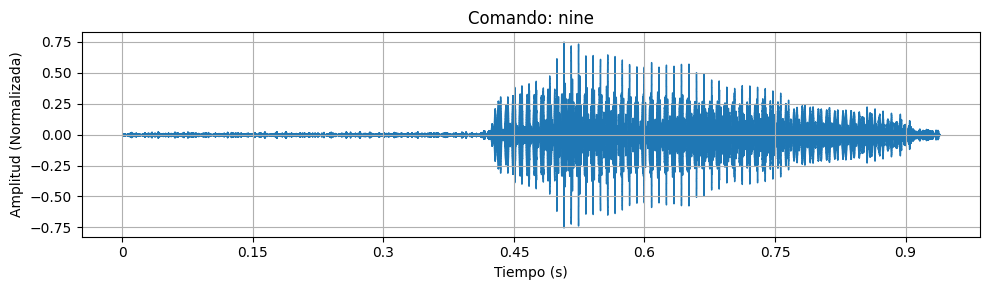

Audio 2: speech_data/marvin/ab5d7179_nohash_0.wav [Punto A.2]


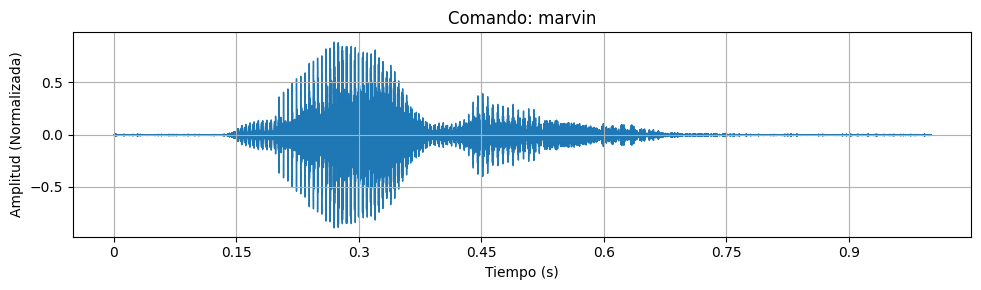

Audio 3: speech_data/left/29229c21_nohash_3.wav [Punto A.2]


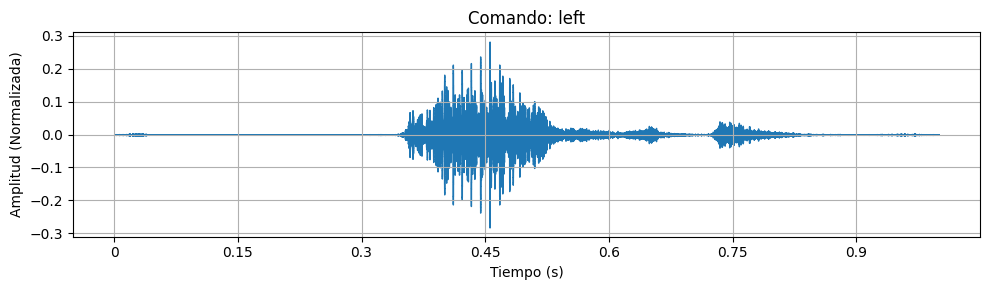

In [10]:
# --- PUNTO A.2: Cargar al menos tres audios utilizando librosa ---
audio_files = glob.glob(os.path.join(extract_folder, "*/*.wav"))
samples_to_load = random.sample(audio_files, 3)

for i, path in enumerate(samples_to_load):
    y, sr = librosa.load(path, sr=None)
    print(f"Audio {i+1}: {path} [Punto A.2]")

    # --- PUNTO A.3: Reproducir y Graficar (ahora con labels) ---
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)

    plt.title(f"Comando: {os.path.basename(os.path.dirname(path))}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (Normalizada)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    ipd.display(ipd.Audio(y, rate=sr)) # [Punto A.3]

En los gráficos de las formas de onda se observa que la amplitud toma valores positivos y negativos. Esto se debe a que el micrófono convierte variaciones de presión del aire en una señal eléctrica y la señal oscila alrededor de cero. Cuando la curva va positiva, la tensión instantánea está para un lado de la referencia, cuando va negativa, está para el otro lado. En términos prácticos, lo importante es la magnitud de la amplitud y su evolución temporal, ya que eso refleja la energía y la estructura de la palabra pronunciada.

Además, al cargar los audios se utilizó `librosa.load(path, sr=None)`. Esto es importante porque los archivos originales de la base están muestreados a 16 kHz, y si no se especifica `sr=None`, `librosa` los remuestrea automáticamente a 22.05 kHz. Aunque eso no necesariamente rompe el análisis, sí modifica innecesariamente los datos originales, por lo que conviene mantener la frecuencia de muestreo original del dataset.

### Punto 4

En esta parte del TP el objetivo es pasar del audio crudo a una representación que muestre cómo se reparte la energía en frecuencia a medida que pasa el tiempo. Para eso se usa la STFT: en vez de calcular una sola transformada de Fourier para todo el audio, se divide la señal en tramos cortos y se calcula una FFT en cada uno. Esto es necesario porque una palabra no es estacionaria, las frecuencias presentes al principio, en el medio y al final no son las mismas. Por eso interesa mirar el contenido espectral localmente en el tiempo y no solo en promedio.

En señales de voz suelen usarse ventanas de entre 20 y 40 ms porque, en intervalos tan cortos, la señal puede considerarse aproximadamente estacionaria o cuasiestacionaria: su contenido espectral no cambia demasiado dentro de esa ventana. Eso permite que la FFT tenga sentido como una descripción local del sonido. Si la ventana fuera mucho más larga, mezclaría partes distintas de la palabra y se perdería información temporal importante. Mientras que si fuera demasiado corta, la resolución en frecuencia sería muy pobre. En este caso, usar `n_fft = 512` con \($f_s = 16\text{ kHz}$\) equivale a una ventana de 32 ms, que cae dentro de ese rango típico. La resolución en frecuencia resultante es de \($16000/512 = 31.25$\) Hz, que es suficiente para este TP porque no se busca medir frecuencias exactas con gran precisión, sino capturar cómo se distribuye la energía espectral de la voz y cómo esa distribución cambia en el tiempo. En otras palabras, para distinguir palabras no alcanza con mirar solo el tiempo ni solo la frecuencia: interesa una representación tiempo-frecuencia que conserve ambas cosas de manera equilibrada.

Por otro lado, las ventanas se toman con 50\% de solapamiento, es decir, cada nueva ventana empieza a mitad de la anterior. Esto se hace para no “saltearse” información entre bloques consecutivos y para que la representación cambie de forma más suave en el tiempo. Si no hubiera solapamiento, podrían perderse transiciones importantes entre sonidos.

Antes de hacer cada FFT se aplica una ventana de Hann. La idea es suavizar los bordes de cada tramo, porque cortar la señal de golpe genera discontinuidades artificiales que ensucian el espectro. La ventana de Hann reduce ese efecto y hace que la energía quede mejor ubicada en las frecuencias donde realmente está. Como la señal de audio es real, el espectro tiene una parte simétrica, así que solo hace falta trabajar con una mitad.


In [11]:
# --- PUNTO A.4: Calcular la transformada de Fourier de corto tiempo (STFT) ---
def calcular_stft_tp(y):
    # Configuración: FFT 512, Solapamiento 50% (hop 256), Ventana Hann 512
    # Librosa descarta la parte simétrica automáticamente para señales reales.
    stft = librosa.stft(y, n_fft=512, hop_length=256, win_length=512, window='hann')
    return np.abs(stft)2 # Retornamos magnitud al cuadrado (energía)


### Puntos 4 y 5


Luego, en lugar de usar todos los bins de frecuencia, el espectro se resume en 20 bandas de energía. Esto simplifica mucho la información: en vez de guardar todos los detalles finos, se conserva cuánto contenido energético hay en cada zona de frecuencia. Finalmente, esas energías se pasan a dB, lo que comprime el rango de valores y hace más fácil comparar partes fuertes y débiles de la señal. En resumen, esta etapa transforma cada audio en una representación compacta y mucho más útil para clasificar comandos de voz.

In [ ]:
# --- PUNTO A.5: Descomponer el espectro en 20 bandas de energía ---
def calcular_bandas_20(espectro):
    n_bins, n_frames = espectro.shape
    n_bandas = 20
    bins_por_banda = n_bins // n_bandas

    energias = np.zeros((n_bandas, n_frames))
    for i in range(n_bandas):
        inicio = i * bins_por_banda
        fin = (i + 1) * bins_por_banda
        # Sumatoria de |X[k]|^2 para la banda i-ésima
        energias[i, :] = np.sum(espectro[inicio:fin, :], axis=0)
    return energias

# --- PUNTO A.6: Convertir la energía en dB ---
def energia_a_db(E):
    E_max = np.max(E)
    eps = 1e-10 # Epsilon para evitar log(0)
    # Fórmula: 10 * log10(E / E_max)
    return 10 * np.log10((E + eps) / (E_max + eps))

Procesamiento finalizado. Matriz resultante: (20, 59)


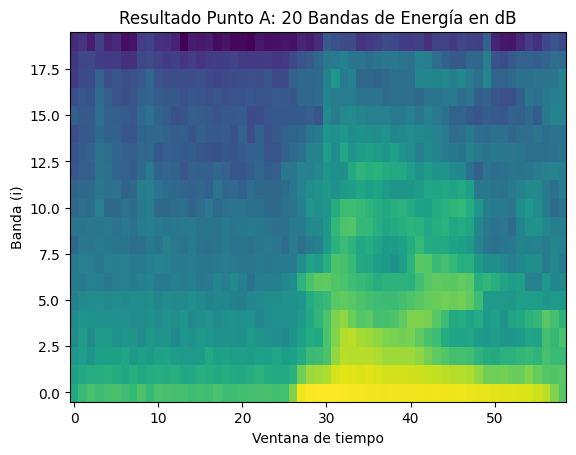

In [12]:
# Demostración del flujo completo del Inciso (a)
audio_test, sr_test = librosa.load(samples_to_load[0], sr=None)

# Ejecución secuencial de los puntos 4, 5 y 6
espectro_pot = calcular_stft_tp(audio_test)      # Punto 4
bandas_raw = calcular_bandas_20(espectro_pot)   # Punto 5
bandas_db = energia_a_db(bandas_raw)            # Punto 6

print(f"Procesamiento finalizado. Matriz resultante: {bandas_db.shape}")
plt.imshow(bandas_db, aspect='auto', origin='lower')
plt.title("Resultado Punto A: 20 Bandas de Energía en dB")
plt.ylabel("Banda (i)")
plt.xlabel("Ventana de tiempo")
plt.show()

## Ítem B

## Ítem C